
# Assignment: Shadow-Invariant Vision with OpenCV and Kornia

## Motivation

A shadow can create a strong image boundary even though there is no corresponding boundary in scene geometry or material.

Before beginning, watch [a Tesla on FSD 14.2.2.5 swerve for a shadow](https://x.com/EliasMartinez/status/2034946481744929113), reported by Elias Martinez in March 2026. The driver disengaged.

The central question of this assignment is:

> Can we construct an image representation that responds strongly to changes in surface reflectance but weakly to changes caused only by illumination?

You will implement a shadow-invariant representation inspired by Chapter 10 of Peter Corke's *Robotics, Vision & Control*.

[Download Chapter 10, Light and Color (PDF, 40 pages)](https://artifacts.aegeanai.com/pdf/corke-rvc3/ch10-light-and-color.pdf)

Reference notebook:

https://github.com/petercorke/RVC3-python/blob/main/notebooks/chap10.ipynb

Focus on:

- §10.1 Spectral Representation of Light
- §10.2 Color
- §10.4 Application: Color Images
- §10.4.2 Shadow Removal

You will first implement the relevant computations with NumPy and OpenCV, then port the final shadow-invariant pipeline to PyTorch/Kornia.



## Learning Objectives

By the end of this assignment, you should be able to:

1. Explain why shadows alter image measurements without altering surface material.
2. Relate illumination spectra to measured color.
3. Compare RGB, HSV, and Lab for illuminated and shadowed regions.
4. Construct a log-chromaticity representation.
5. Compute a one-dimensional shadow-invariant image.
6. Quantitatively evaluate shadow suppression.
7. Port the final computation to a PyTorch/Kornia tensor pipeline.



# 1. Development Environment

Use the course development environment:

https://github.com/pantelis/eng-ai-agents

Open the repository in VS Code as a Dev Container.

Inside the container run:

```bash
make start
make install-notebooks
source .venv/bin/activate
```

`make start` alone installs only the base dependencies. `make install-notebooks` adds OpenCV, PyTorch and Kornia, which the sections below use.

GPU acceleration is not required for full credit.


In [21]:
!pip install kornia

In [22]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import kornia
import time

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("Kornia:", kornia.__version__)
print("CUDA available:", torch.cuda.is_available())


OpenCV: 5.0.0
NumPy: 2.1.3
PyTorch: 2.11.0+cpu
Kornia: 0.8.3
CUDA available: False



# 2. Why Does a Shadow Change an Image?

A simplified image-formation model is

$$
I_k =
\int E(\lambda)R(\lambda)Q_k(\lambda)\,d\lambda,
$$

where

- $E(\lambda)$ is illumination,
- $R(\lambda)$ is surface reflectance,
- $Q_k(\lambda)$ is the spectral response of camera channel $k$.

The key observation is:

$$
\text{measured pixel value} \neq \text{surface reflectance alone}.
$$

Measured RGB depends on both the material and the illumination.

In a cast shadow, the material reflectance is approximately unchanged, but the illumination reaching the surface changes.



## 2.1 Blackbody Illumination

Implement Planck's law:

$$
B(\lambda,T)
=
\frac{2hc^2}{\lambda^5}
\frac{1}
{\exp\left(\frac{hc}{\lambda k_BT}\right)-1}.
$$

Plot normalized spectra for:

$$
T_1 = 2600\text{ K},
\qquad
T_2 = 5778\text{ K}.
$$

Answer briefly:

1. Why can the same material produce different RGB values under these two illuminants?
2. In a cast shadow, what changes: reflectance or illumination?


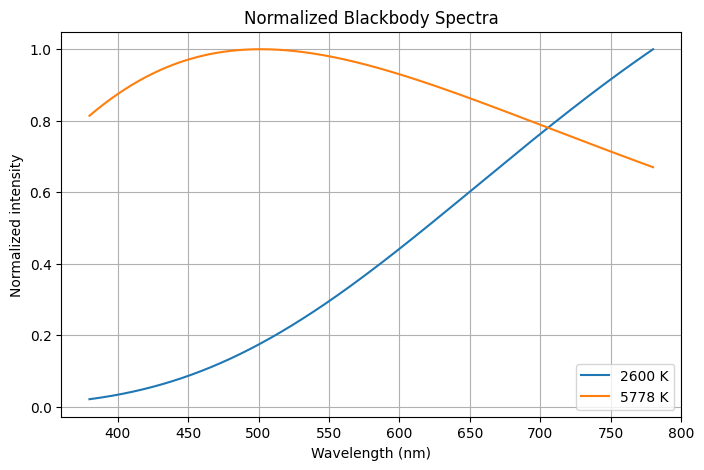

In [23]:
def blackbody(wavelength_m, temperature_k):
    h = 6.62607015e-34
    c = 2.99792458e8
    kB = 1.380649e-23

    numerator = 2 * h * c**2
    denominator = wavelength_m**5 * (
        np.exp((h * c) / (wavelength_m * kB * temperature_k)) - 1
    )

    return numerator / denominator


wavelength_nm = np.linspace(380, 780, 400)
wavelength_m = wavelength_nm * 1e-9

lamp = blackbody(wavelength_m, 2600)
sun = blackbody(wavelength_m, 5778)

# Normalize each spectrum
lamp = lamp / np.max(lamp)
sun = sun / np.max(sun)

# Plot both spectra
plt.figure(figsize=(8, 5))
plt.plot(wavelength_nm, lamp, label="2600 K")
plt.plot(wavelength_nm, sun, label="5778 K")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized intensity")
plt.title("Normalized Blackbody Spectra")
plt.legend()
plt.grid(True)
plt.show()

### Short Answer

- **Same material, different illuminants:** The same material can produce different RGB values because different illuminants have different spectral distributions. The camera receives different amounts of red, green, and blue light even though the surface reflectance is unchanged.

- **What changes in a cast shadow:** The illumination changes, while the surface reflectance remains approximately unchanged.


# 3. Observe a Shadow in Different Color Spaces

Use Corke's `parks.png` image or another supplied outdoor image containing a strong cast shadow.

Load the image with OpenCV and select two small regions of the same physical surface:

- one directly illuminated,
- one inside the shadow.

You will compare the regions in RGB, HSV, and Lab.


Image shape (H, W, C): (2448, 3264, 3)


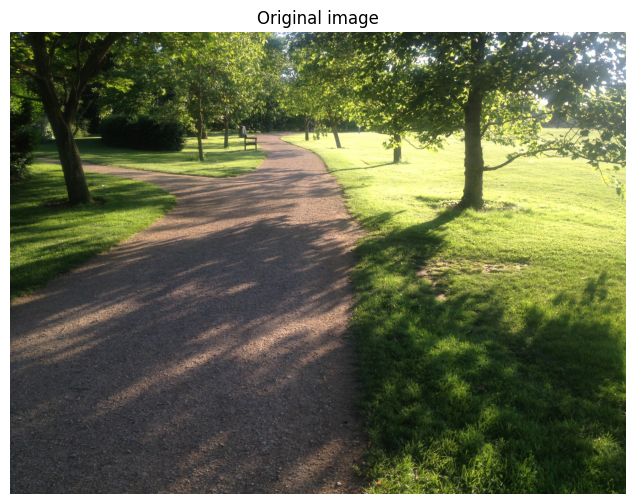

In [24]:

import os
import urllib.request

# parks.png is the outdoor scene Corke uses in chapter 10. It ships with the
# Machine Vision Toolbox data package (Peter Corke, MIT license).
IMAGE_URL = (
    "https://raw.githubusercontent.com/petercorke/machinevision-toolbox-python/"
    "main/packages/mvtb-data/mvtbdata/images/parks.png"
)
IMAGE_PATH = "parks.png"  # TODO: point this at your own image if you prefer

if not os.path.exists(IMAGE_PATH):
    urllib.request.urlretrieve(IMAGE_URL, IMAGE_PATH)

image_bgr = cv2.imread(IMAGE_PATH)
if image_bgr is None:
    raise FileNotFoundError(
        f"Could not load {IMAGE_PATH}. Check the path, or download the image "
        f"yourself from {IMAGE_URL}."
    )

print("Image shape (H, W, C):", image_bgr.shape)

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Original image")
plt.show()



## 3.1 Define Illuminated and Shadowed Regions

Choose two rectangular regions containing the same material.

Store them as:

```python
(x1, y1, x2, y2)
```

where `(x1, y1)` is the upper-left corner and `(x2, y2)` is the lower-right corner.


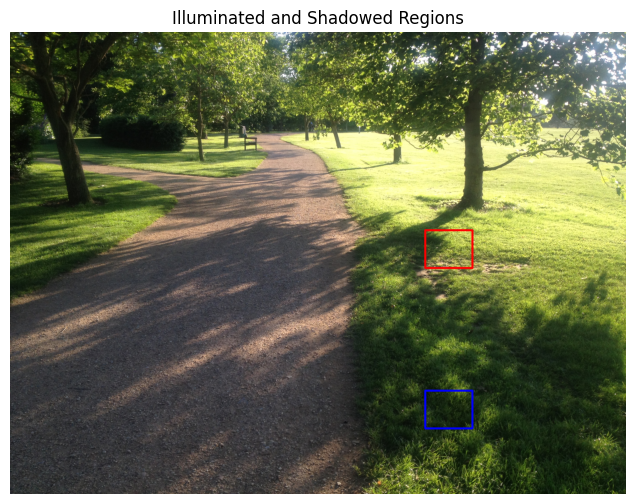

In [25]:
# Choose two regions of the same material (grass):
# one illuminated and one inside the shadow.

lit_roi = (2200, 1050, 2450, 1250)
shadow_roi = (2200, 1900, 2450, 2100)

def crop_roi(image, roi):
    x1, y1, x2, y2 = roi
    return image[y1:y2, x1:x2]

def mean_color(image, roi):
    patch = crop_roi(image, roi)
    return patch.reshape(-1, patch.shape[-1]).mean(axis=0)

# Visualize the selected regions
display_img = image_rgb.copy()

cv2.rectangle(display_img,
              (lit_roi[0], lit_roi[1]),
              (lit_roi[2], lit_roi[3]),
              (255, 0, 0), 10)

cv2.rectangle(display_img,
              (shadow_roi[0], shadow_roi[1]),
              (shadow_roi[2], shadow_roi[3]),
              (0, 0, 255), 10)

plt.figure(figsize=(10, 6))
plt.imshow(display_img)
plt.title("Illuminated and Shadowed Regions")
plt.axis("off")
plt.show()

In [26]:

hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)

rgb_lit = mean_color(image_rgb, lit_roi)
rgb_shadow = mean_color(image_rgb, shadow_roi)

hsv_lit = mean_color(hsv, lit_roi)
hsv_shadow = mean_color(hsv, shadow_roi)

lab_lit = mean_color(lab, lit_roi)
lab_shadow = mean_color(lab, shadow_roi)

print("RGB lit:    ", rgb_lit)
print("RGB shadow: ", rgb_shadow)
print("HSV lit:    ", hsv_lit)
print("HSV shadow: ", hsv_shadow)
print("Lab lit:    ", lab_lit)
print("Lab shadow: ", lab_shadow)


RGB lit:     [133.38088 140.7705   68.86232]
RGB shadow:  [28.31464 43.99518 17.38876]
HSV lit:     [ 34.29624 132.75992 142.71836]
HSV shadow:  [ 49.63236 154.49486  43.99518]
Lab lit:     [142.41922 114.47986 164.40574]
Lab shadow:  [ 40.23962 115.76396 141.96108]



### Questions

1. Which components change most strongly across the shadow?
2. Does converting to HSV or Lab completely remove the shadow?
3. Why is separating intensity from chromatic information useful?


### Answers

1. **Which components change most strongly across the shadow?**  
The intensity-related components change the most strongly. The RGB values decrease significantly in the shadow. In HSV, the V (Value) component decreases strongly, and in Lab, the L (Lightness) component also decreases strongly.

2. **Does converting to HSV or Lab completely remove the shadow?**  
No. Converting the image to HSV or Lab does not completely remove the shadow. The shadow is still represented by changes in the V component of HSV and the L component of Lab.

3. **Why is separating intensity from chromatic information useful?**  
Separating intensity from chromatic information helps distinguish changes caused by illumination from changes caused by the actual surface color. This is useful for reducing the effect of shadows while preserving important color information.


# 4. Implement the Shadow-Invariant Image

This is the main part of the assignment.

Do not use Corke's `shadow_invariant()` function.

You will implement:

1. sRGB linearization
2. log chromaticity
3. 2-D projection
4. a 1-D invariant image



## 4.1 Convert sRGB to Linear RGB

Convert the image to floating-point RGB in $[0,1]$.

Implement the inverse sRGB transfer function:

$$
C_{\text{linear}}
=
\begin{cases}
C_{\text{sRGB}}/12.92,
&
C_{\text{sRGB}}\leq0.04045
\\[4pt]
\left(
\frac{C_{\text{sRGB}}+0.055}{1.055}
\right)^{2.4},
&
\text{otherwise}.
\end{cases}
$$


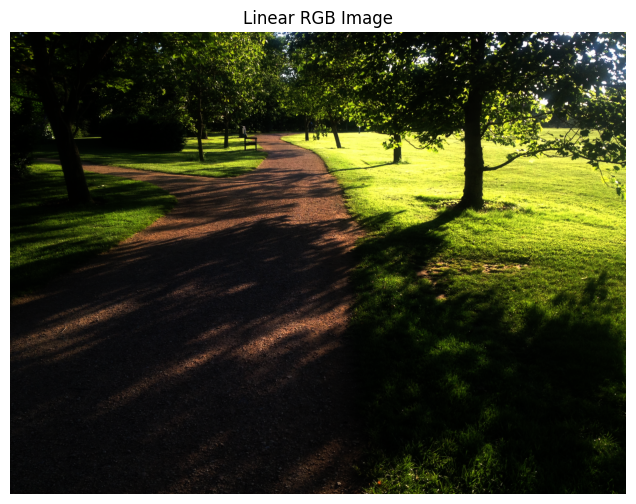

In [27]:
def srgb_to_linear(rgb):
    # rgb must be float32/float64 in [0, 1]
    return np.where(
        rgb <= 0.04045,
        rgb / 12.92,
        ((rgb + 0.055) / 1.055) ** 2.4
    )

rgb = image_rgb.astype(np.float32) / 255.0
linear_rgb = srgb_to_linear(rgb)

# Display linear RGB after clipping to [0,1]
plt.figure(figsize=(10, 6))
plt.imshow(np.clip(linear_rgb, 0, 1))
plt.axis("off")
plt.title("Linear RGB Image")
plt.show()


## 4.2 Log Chromaticity

For each pixel compute the geometric mean

$$
M=(RGB)^{1/3}.
$$

Then define

$$
\rho_R=\log\frac{R}{M},
\qquad
\rho_G=\log\frac{G}{M},
\qquad
\rho_B=\log\frac{B}{M}.
$$

Use a small $\epsilon$ for numerical stability.

Verify numerically that

$$
\rho_R+\rho_G+\rho_B\approx0.
$$


In [28]:
def log_chromaticity(linear_rgb, eps=1e-6):
    # 1. clamp values with eps
    rgb_safe = np.maximum(linear_rgb, eps)

    # 2. compute geometric mean M
    M = np.cbrt(
        rgb_safe[..., 0] *
        rgb_safe[..., 1] *
        rgb_safe[..., 2]
    )

    # 3. compute rho_R, rho_G, rho_B
    rho_R = np.log(rgb_safe[..., 0] / M)
    rho_G = np.log(rgb_safe[..., 1] / M)
    rho_B = np.log(rgb_safe[..., 2] / M)

    # 4. stack into an H x W x 3 array
    return np.stack([rho_R, rho_G, rho_B], axis=-1)

rho = log_chromaticity(linear_rgb)

# Verify rho_R + rho_G + rho_B is approximately zero
rho_sum = rho[..., 0] + rho[..., 1] + rho[..., 2]

print("Maximum absolute sum:", np.max(np.abs(rho_sum)))
print("Mean absolute sum:", np.mean(np.abs(rho_sum)))

Maximum absolute sum: 9.536743e-07
Mean absolute sum: 8.274932e-08



## 4.3 Project to a Two-Dimensional Chromaticity Plane

Use the orthonormal basis

$$
u_1=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
-1\\
0
\end{bmatrix},
\qquad
u_2=
\frac{1}{\sqrt{6}}
\begin{bmatrix}
1\\
1\\
-2
\end{bmatrix}.
$$

Compute

$$
\chi_1=u_1^T\rho,
\qquad
\chi_2=u_2^T\rho.
$$


In [29]:
u1 = np.array([1.0, -1.0, 0.0]) / np.sqrt(2.0)
u2 = np.array([1.0, 1.0, -2.0]) / np.sqrt(6.0)

# Compute chi1 and chi2 for all pixels
chi1 = np.sum(rho * u1, axis=-1)
chi2 = np.sum(rho * u2, axis=-1)

print("chi1 shape:", chi1.shape)
print("chi2 shape:", chi2.shape)
print("chi1 range:", chi1.min(), "to", chi1.max())
print("chi2 range:", chi2.min(), "to", chi2.max())

chi1 shape: (2448, 3264)
chi2 shape: (2448, 3264)
chi1 range: -2.0063325297602193 to 0.8829564038666265
chi2 range: -1.5913634075833656 to 10.308406185784673



## 4.4 Plot Illuminated and Shadowed Pixels in Log-Chromaticity Space

Plot pixels from the two selected ROIs in $(\chi_1,\chi_2)$ coordinates.

Use different markers or colors for the illuminated and shadowed regions.

Do the two groups appear displaced primarily along a common direction?


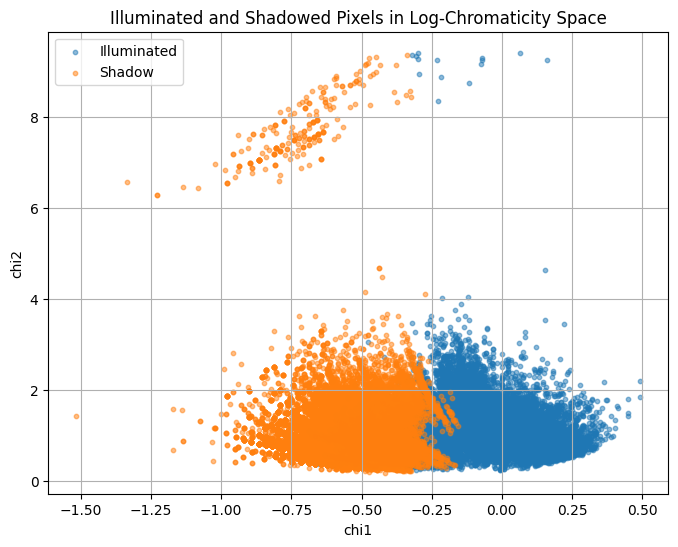

In [30]:
def roi_values(image_2d, roi):
    x1, y1, x2, y2 = roi
    return image_2d[y1:y2, x1:x2].ravel()

# Get chi1 and chi2 values from illuminated and shadow regions
lit_x = roi_values(chi1, lit_roi)
lit_y = roi_values(chi2, lit_roi)

shadow_x = roi_values(chi1, shadow_roi)
shadow_y = roi_values(chi2, shadow_roi)

# Plot the two regions in log-chromaticity space
plt.figure(figsize=(8, 6))

plt.scatter(lit_x, lit_y, s=10, alpha=0.5, label="Illuminated")
plt.scatter(shadow_x, shadow_y, s=10, alpha=0.5, label="Shadow")

plt.xlabel("chi1")
plt.ylabel("chi2")
plt.title("Illuminated and Shadowed Pixels in Log-Chromaticity Space")
plt.legend()
plt.grid(True)
plt.show()

### Answer

Yes. The illuminated and shadowed pixels form different clusters in the log-chromaticity space. The two groups appear to be displaced mainly along a common direction, showing that the change in illumination caused by the shadow produces a systematic shift in the chromaticity values.


## 4.5 Shadow-Invariant Projection

Reproduce Corke's fixed-angle example using

$$
\theta=0.7\text{ rad}.
$$

Compute

$$
I_{\text{inv}}
=
\chi_1\cos\theta
+
\chi_2\sin\theta.
$$

Normalize only for visualization.


Invariant shape: (2448, 3264)
Invariant range: -2.1485899376771864 to 6.771997525771661


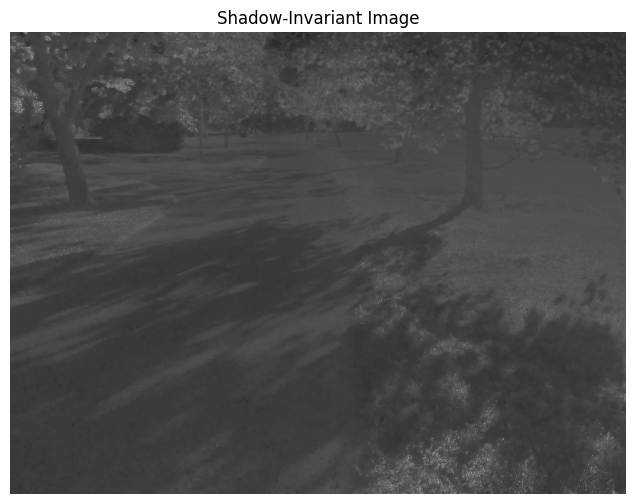

In [31]:
theta = 0.7

# Compute the shadow-invariant projection
invariant = chi1 * np.cos(theta) + chi2 * np.sin(theta)

# Normalize for display only
invariant_display = cv2.normalize(
    invariant, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

print("Invariant shape:", invariant.shape)
print("Invariant range:", invariant.min(), "to", invariant.max())

plt.figure(figsize=(10, 6))
plt.imshow(invariant_display, cmap="gray")
plt.title("Shadow-Invariant Image")
plt.axis("off")
plt.show()


Display side-by-side:

1. original RGB image,
2. ordinary grayscale image,
3. shadow-invariant image.

Then answer:

1. Which shadow boundaries became weaker?
2. Which physical or material boundaries remained?


### Answers

**1. Which shadow boundaries became weaker?**

The strong shadow boundaries caused by the trees across the path and grass became weaker in the shadow-invariant image. The large brightness differences between illuminated and shadowed regions were reduced.

**2. Which physical or material boundaries remained?**

Physical and material boundaries such as the edges of the trees, the boundary between the path and grass, and other surface structures remained visible. These boundaries correspond to actual changes in the scene rather than changes caused only by illumination.

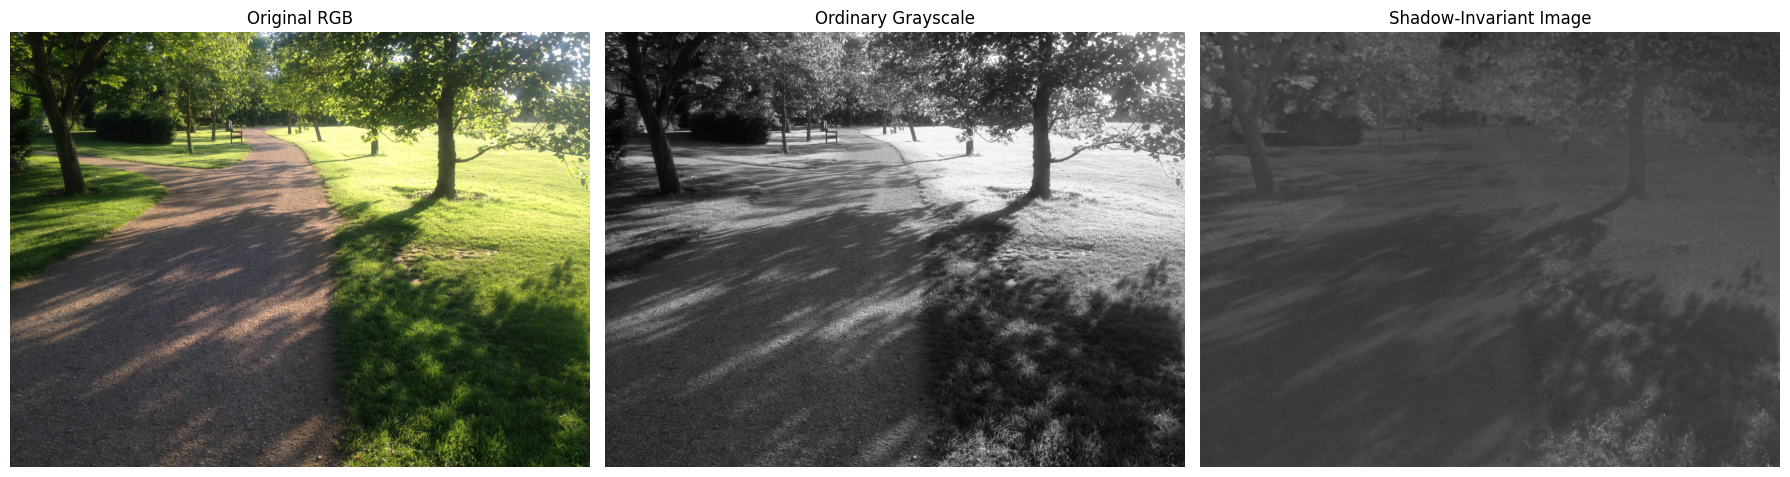

In [32]:
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Ordinary Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(invariant_display, cmap="gray")
plt.title("Shadow-Invariant Image")
plt.axis("off")

plt.tight_layout()
plt.show()


# 5. Quantitative Evaluation

Use the same illuminated and shadowed ROIs.

For grayscale compute

$$
\Delta_{\text{gray}}
=
|\mu_{\text{lit}}-\mu_{\text{shadow}}|.
$$

For the invariant image compute

$$
\Delta_{\text{inv}}
=
|\mu_{\text{lit}}^{\text{inv}}
-
\mu_{\text{shadow}}^{\text{inv}}|.
$$

A successful representation should approximately satisfy

$$
\Delta_{\text{inv}} < \Delta_{\text{gray}}.
$$


In [33]:
def mean_scalar(image_2d, roi):
    return roi_values(image_2d, roi).mean()

# Mean values in illuminated and shadow regions
gray_lit = mean_scalar(gray, lit_roi)
gray_shadow = mean_scalar(gray, shadow_roi)

inv_lit = mean_scalar(invariant, lit_roi)
inv_shadow = mean_scalar(invariant, shadow_roi)

# Compute differences
delta_gray = abs(gray_lit - gray_shadow)
delta_inv = abs(inv_lit - inv_shadow)

print("Gray illuminated mean:", gray_lit)
print("Gray shadow mean:", gray_shadow)
print("Delta gray:", delta_gray)

print("Invariant illuminated mean:", inv_lit)
print("Invariant shadow mean:", inv_shadow)
print("Delta invariant:", delta_inv)

print("Delta invariant < Delta gray:", delta_inv < delta_gray)

Gray illuminated mean: 130.36692
Gray shadow mean: 36.24308
Delta gray: 94.12384
Invariant illuminated mean: 0.6650783010133556
Invariant shadow mean: 0.14960506210008073
Delta invariant: 0.5154732389132749
Delta invariant < Delta gray: True



## 5.1 Compare Edges

Use OpenCV Canny on:

1. the ordinary grayscale image,
2. the normalized shadow-invariant image.

Look for one shadow edge and one real material/object edge.

The desired behavior is:

- weaker response at the shadow boundary,
- preservation of real scene boundaries.


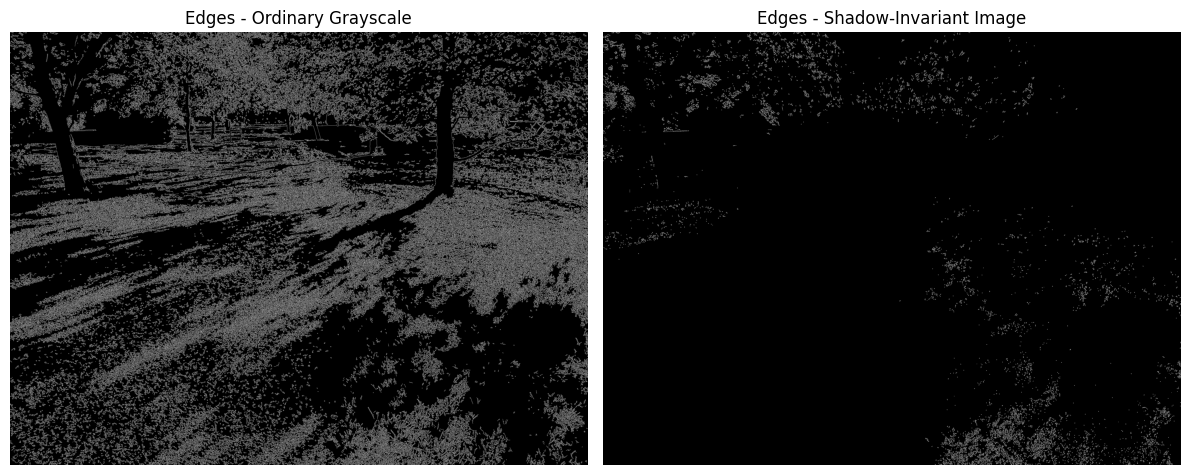

In [34]:
# Canny edge detection
edges_gray = cv2.Canny(gray, 50, 150)
edges_inv = cv2.Canny(invariant_display, 50, 150)

# Display both edge maps
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(edges_gray, cmap='gray')
plt.title("Edges - Ordinary Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges_inv, cmap='gray')
plt.title("Edges - Shadow-Invariant Image")
plt.axis("off")

plt.tight_layout()
plt.show()


# 6. Port the Final Pipeline to PyTorch and Kornia

The goal of this section is to express the same classical computer-vision pipeline as tensor operations.

This allows:

- batching,
- GPU execution,
- automatic differentiation.

Kornia provides differentiable computer-vision operators that integrate directly with PyTorch computation graphs.


In [35]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rgb_t = (
    torch.from_numpy(image_rgb)
    .permute(2, 0, 1)
    .unsqueeze(0)
    .float()
    .div(255.0)
    .to(device)
)

print("Tensor shape:", rgb_t.shape)
print("Device:", rgb_t.device)


Tensor shape: torch.Size([1, 3, 2448, 3264])
Device: cpu



## 6.1 Linear RGB with Kornia

Use:

```python
kornia.color.rgb_to_linear_rgb(...)
```

Then reproduce the same log-chromaticity and projection equations using PyTorch tensor operations.


In [36]:
linear_t = kornia.color.rgb_to_linear_rgb(rgb_t)

def shadow_invariant_torch(linear_rgb_t, theta=0.7, eps=1e-6):
    # Expected input shape: B x 3 x H x W

    # 1. Clamp channels with eps
    x = torch.clamp(linear_rgb_t, min=eps)

    R = x[:, 0, :, :]
    G = x[:, 1, :, :]
    B = x[:, 2, :, :]

    # 2. Compute geometric mean
    M = (R * G * B).pow(1.0 / 3.0)

    # 3. Compute log chromaticities
    rho_R = torch.log(R / M)
    rho_G = torch.log(G / M)
    rho_B = torch.log(B / M)

    # 4. Project using u1 and u2
    chi1 = (rho_R - rho_G) / torch.sqrt(
        torch.tensor(2.0, device=x.device)
    )

    chi2 = (rho_R + rho_G - 2.0 * rho_B) / torch.sqrt(
        torch.tensor(6.0, device=x.device)
    )

    # 5. Compute shadow-invariant projection
    invariant = (
        chi1 * torch.cos(torch.tensor(theta, device=x.device))
        + chi2 * torch.sin(torch.tensor(theta, device=x.device))
    )

    # Return shape: B x H x W
    return invariant

invariant_t = shadow_invariant_torch(linear_t, theta=0.7)

print("Linear tensor shape:", linear_t.shape)
print("Invariant tensor shape:", invariant_t.shape)

Linear tensor shape: torch.Size([1, 3, 2448, 3264])
Invariant tensor shape: torch.Size([1, 2448, 3264])



## 6.2 Compare NumPy/OpenCV and PyTorch/Kornia Results

Compute

$$
\mathrm{MAE}
=
\frac{1}{N}
\sum_i
|I_i^{\mathrm{NumPy}}
-
I_i^{\mathrm{PyTorch}}|.
$$

The two implementations should be numerically very similar.


In [37]:
# Convert PyTorch result to NumPy
invariant_t_np = invariant_t.squeeze(0).detach().cpu().numpy()

# Compute Mean Absolute Error
mae = np.mean(np.abs(invariant - invariant_t_np))

print("MAE:", mae)

MAE: 4.7587889856798916e-08



## 6.3 Optional GPU Batch Experiment

If CUDA is available, process a batch of 32 identical images.

Report:

- execution device,
- batch shape,
- elapsed time.

No GPU speedup is required for full credit.


In [38]:
if torch.cuda.is_available():
    batch = rgb_t.repeat(32, 1, 1, 1)
    batch_linear = kornia.color.rgb_to_linear_rgb(batch)

    torch.cuda.synchronize()
    t0 = time.perf_counter()

    batch_inv = shadow_invariant_torch(batch_linear, theta=0.7)

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    print("Execution device:", batch.device)
    print("Batch shape:", batch.shape)
    print("Elapsed:", elapsed)

else:
    print("CUDA not available; GPU timing is optional.")

CUDA not available; GPU timing is optional.



# 7. Discussion

Return to the autonomous-driving example at the beginning.

Answer in approximately one paragraph:

1. Why does the shadow generate strong image structure even though there is no new physical object?
2. What quantity does the invariant projection attempt to suppress?
3. Why can preserving reflectance-related edges while suppressing illumination edges help perception?
4. Why would this classical method still be insufficient by itself for autonomous driving?

Consider geometry, depth, semantics, temporal reasoning, learned representations, and sensor fusion.


## 7. Discussion

### 1. Why does the shadow generate strong image structure even though there is no new physical object?

A shadow generates strong image structure because it causes a significant change in illumination and pixel intensity. Even though there is no new physical object at the shadow boundary, the sudden change from a bright region to a dark region creates a strong contrast in the image. As a result, an image-processing system may detect the shadow boundary as a strong edge even though it does not represent an actual object or material boundary.

### 2. What quantity does the invariant projection attempt to suppress?

The invariant projection attempts to suppress changes in the image that are caused mainly by illumination, especially the intensity differences between illuminated and shadowed regions. By projecting the log-chromaticity values in a suitable direction, the method reduces the effect of shadows while keeping useful information about the actual surfaces and materials in the scene.

### 3. Why can preserving reflectance-related edges while suppressing illumination edges help perception?

Preserving reflectance-related edges is useful because these edges often represent real changes in objects, surfaces, or materials in the environment. In contrast, illumination edges may be created only by lighting or shadows and do not necessarily represent a physical boundary. Therefore, suppressing illumination edges while preserving reflectance-related edges can help a vision system focus on meaningful scene structure and reduce confusion caused by shadows.

### 4. Why would this classical method still be insufficient by itself for autonomous driving?

This classical shadow-invariant method is not sufficient by itself for autonomous driving because driving requires a much deeper understanding of the environment than simply reducing shadow effects. An autonomous vehicle must understand geometry and depth, recognize objects and their semantic meaning, track motion over time, and predict changes in the scene. Modern systems also use learned representations and sensor fusion from cameras, LiDAR, radar, and other sensors to make reliable driving decisions. Therefore, shadow-invariant processing can be useful, but it is only one small part of a complete autonomous-driving perception system.


# Deliverables

Your notebook must execute from beginning to end, and you must submit it with all outputs saved.

Required outputs:

- two blackbody curves,
- RGB/HSV/Lab comparison,
- log-chromaticity scatter plot,
- shadow-invariant image,
- quantitative shadow comparison,
- OpenCV edge comparison,
- PyTorch/Kornia implementation,
- short final discussion.

## Submitting

Follow the [assignment submission guide](https://aegean.ai/aiml-common/resources/environment/assignment-submission). Commit this notebook with all cell outputs saved, and submit the complete GitHub URL of its directory.

The per-component points are on the assignment page.



# References

1. Peter Corke, *Robotics, Vision & Control: Fundamental Algorithms in Python*, 3rd ed., Springer, Chapter 10. [Download the chapter (PDF)](https://artifacts.aegeanai.com/pdf/corke-rvc3/ch10-light-and-color.pdf)
2. G. D. Finlayson, S. D. Hordley, and M. S. Drew, "Removing Shadows from Images," ECCV, 2002.
3. G. D. Finlayson, M. S. Drew, and C. Lu, "Intrinsic Images by Entropy Minimization," ECCV, 2004.
4. G. D. Finlayson, S. D. Hordley, C. Lu, and M. S. Drew, "On the Removal of Shadows from Images," IEEE TPAMI, 2006.
5. Kornia documentation: https://kornia.readthedocs.io/
6. OpenCV documentation: https://docs.opencv.org/
